โค๊ดคำนวณค่าเฉลี่ยและส่วนเบี่บงเบนมาตรฐานของ Intensity ของทุกไฟล์ในโฟลเดอร์ NdatasetCSV

In [1]:
import os
import pandas as pd

# Specify the folder path
folder_path = "NdatasetCSV"

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

# Create empty lists to store the calculated statistics
average_intensity_values = []
std_dev_intensity_values = []

# Loop through each CSV file and calculate statistics for 'Intensity' column
for csv_file in csv_files:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Read the CSV file into a DataFrame
    df = pd.read_csv(file_path)

    # Check if 'Intensity' column exists in the DataFrame
    if 'Intensity' in df.columns:
        # Group data by 'Order' and 'Color' columns, then calculate mean and standard deviation
        grouped_data = df.groupby(['Order', 'Color'])['Intensity']
        mean_intensity = grouped_data.mean()
        std_dev_intensity = grouped_data.std()

        # Append the calculated statistics to the lists
        average_intensity_values.append(mean_intensity)
        std_dev_intensity_values.append(std_dev_intensity)
    else:
        print(f"Intensity column not found in file: {csv_file}")

# Combine the calculated statistics from all files into one DataFrame
average_intensity_df = pd.concat(average_intensity_values, axis=1)
std_dev_intensity_df = pd.concat(std_dev_intensity_values, axis=1)

# Rename columns to indicate file names
average_intensity_df.columns = csv_files
std_dev_intensity_df.columns = csv_files

# Sort the DataFrame columns by file names
average_intensity_df = average_intensity_df.sort_index(axis=1)
std_dev_intensity_df = std_dev_intensity_df.sort_index(axis=1)

# Print the calculated statistics
print("Average Intensity Values:")
print(average_intensity_df)

print("\nStandard Deviation of Intensity Values:")
print(std_dev_intensity_df)


Average Intensity Values:
               BG_0.csv  BG_1.csv  N100_A.csv  N100_B.csv  N100_NoR.csv  \
Order Color                                                               
6     Black    5.500000      5.50        3.75        3.75          3.75   
      Blue   238.750000    238.00       10.25        9.00        237.25   
      Green  370.000000    373.75       14.00       14.50        354.00   
      Red    312.750000    312.75       23.25       22.25        317.00   
      White  865.500000    868.00       39.75       36.00        853.00   
...                 ...       ...         ...         ...           ...   
24    Black    5.333333      5.00        4.25        4.25          4.50   
      Blue   237.750000    239.25       10.50        9.50        236.00   
      Green  372.750000    371.25       14.25       14.50        358.50   
      Red    311.250000    311.75       24.25       21.75        316.75   
      White  865.500000    865.75       38.75       37.25        855.75   

# บันทึกไฟล์รวมข้อมูล ค่าเฉลี่ยและส่วนเบี่ยงเบนมาตราฐานของไฟล์ในโฟลเดอร์  NdatasetCSV  บันทึกเป็นชื่อ  N_Mean.csv  และ N_StdDeV.csv  ในโฟลเดอร์ StandardData

In [2]:
import os
import pandas as pd

# Specify the folder path
folder_path = "NdatasetCSV"

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

# Create empty DataFrames to store the calculated statistics
average_intensity_df = pd.DataFrame()
std_dev_intensity_df = pd.DataFrame()

# Loop through each CSV file and calculate statistics for 'Intensity' column
for csv_file in csv_files:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Read the CSV file into a DataFrame
    df = pd.read_csv(file_path)

    # Check if 'Intensity' column exists in the DataFrame
    if 'Intensity' in df.columns:
        # Group data by 'Order' and 'Color' columns, then calculate mean and standard deviation
        grouped_data = df.groupby(['Order', 'Color'])['Intensity']
        mean_intensity = grouped_data.mean()
        std_dev_intensity = grouped_data.std()

        # Combine the calculated statistics into the DataFrames
        average_intensity_df[csv_file] = mean_intensity
        std_dev_intensity_df[csv_file] = std_dev_intensity
    else:
        print(f"Intensity column not found in file: {csv_file}")

# Save the calculated statistics as CSV files
output_folder = "StandardData"
output_mean_filename = "N_Mean.csv"
output_stddev_filename = "N_StdDev.csv"
output_mean_path = os.path.join(output_folder, output_mean_filename)
output_stddev_path = os.path.join(output_folder, output_stddev_filename)

# Create the "StandardData" folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Save the DataFrames as CSV files
average_intensity_df.to_csv(output_mean_path)
std_dev_intensity_df.to_csv(output_stddev_path)

# Print the calculated statistics
print("Average Intensity Values:")
print(average_intensity_df)

print("\nStandard Deviation of Intensity Values:")
print(std_dev_intensity_df)

print(f"Calculated statistics saved to {output_mean_path} and {output_stddev_path}")


Average Intensity Values:
             N10_blank.csv  N10_NoR.csv  N4_blank.csv  N20_R.csv  N10_WR.csv  \
Order Color                                                                    
6     Black           3.50         3.00          4.50       4.00        3.25   
      Blue          211.25       240.75        209.75      20.75      259.00   
      Green         326.75       378.50        329.00     120.50      405.00   
      Red           274.75       314.00        275.00     278.50      319.75   
      White         770.75       891.75        774.25     409.25      923.00   
...                    ...          ...           ...        ...         ...   
24    Black           3.00         3.50          4.25       4.75        3.50   
      Blue          212.75       242.25        209.50      20.25      259.25   
      Green         327.75       382.25        331.25     120.50      408.00   
      Red           274.75       315.50        273.25     278.50      320.00   
      White   

# ปรับแต่งหัวตาราง

In [3]:
import pandas as pd

# Function to remove ".csv" from column names and save the modified DataFrame
def remove_csv_extension_and_save(filename):
    # Read the CSV file into a DataFrame
    df = pd.read_csv(filename)

    # Remove the ".csv" from column names
    df.columns = [col.replace('.csv', '') for col in df.columns]

    # Save the modified DataFrame back to the original file
    df.to_csv(filename, index=False)

# List of files to process
file_list = ["StandardData/N_mean.csv", "StandardData/N_stddev.csv"]

# Process each file
for file in file_list:
    remove_csv_extension_and_save(file)
    print(f"Updated {file} with modified column names.")


Updated StandardData/N_mean.csv with modified column names.
Updated StandardData/N_stddev.csv with modified column names.


เปิดไฟล์ N_mean.csv เพื่อดูข้อมูล

In [4]:
import pandas as pd

# Read the "N_mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_mean.csv")

# Display the DataFrame
print(df)


    Order  Color  N10_blank  N10_NoR  N4_blank   N20_R  N10_WR  N2n_NoR  \
0       6  Black       3.50     3.00      4.50    4.00    3.25     5.00   
1       6   Blue     211.25   240.75    209.75   20.75  259.00   263.25   
2       6  Green     326.75   378.50    329.00  120.50  405.00   428.50   
3       6    Red     274.75   314.00    275.00  278.50  319.75   327.50   
4       6  White     770.75   891.75    774.25  409.25  923.00   941.75   
..    ...    ...        ...      ...       ...     ...     ...      ...   
90     24  Black       3.00     3.50      4.25    4.75    3.50     5.00   
91     24   Blue     212.75   242.25    209.50   20.25  259.25   264.75   
92     24  Green     327.75   382.25    331.25  120.50  408.00   428.50   
93     24    Red     274.75   315.50    273.25  278.50  320.00   328.25   
94     24  White     772.00   888.25    776.50  411.50  926.25   942.00   

     N20_A   N20_W  ...  N40_NoR  N6_NoR  N100_R  N40_WR  N20_blank  N100_NoR  \
0     4.25    4.00

In [5]:
import pandas as pd
import os

# Read the "N_mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_mean.csv")

# Calculate the average of the columns following the "Color" column
# Group the data by the "Color" column and calculate the mean
average_by_color = df.groupby("Color").mean()

# Display the result
print("Average by Color:")
print(average_by_color)

# Define the output file path
output_folder = "StandardData"
output_filename = "N_all_Mean.csv"
output_path = os.path.join(output_folder, output_filename)

# Check if the file "N_all_Mean.csv" already exists
if os.path.exists(output_path):
    print(f"'{output_filename}' already exists. Overwriting the file.")

# Save the DataFrame to a CSV file
average_by_color.to_csv(output_path)

print(f"Data saved to '{output_path}' as 'N_all_Mean.csv'.")


Average by Color:
       Order   N10_blank     N10_NoR    N4_blank       N20_R      N10_WR  \
Color                                                                      
Black   15.0    3.421053    3.315789    4.381579    4.223684    3.250000   
Blue    15.0  211.973684  240.184211  212.039474   20.855263  258.434211   
Green   15.0  327.894737  381.500000  331.026316  120.407895  407.855263   
Red     15.0  273.881579  315.105263  273.842105  279.631579  318.723684   
White   15.0  774.276316  888.513158  775.447368  411.315789  925.276316   

          N2n_NoR       N20_A       N20_W      N80_WR  ...     N40_NoR  \
Color                                                  ...               
Black    5.000000    4.197368    4.302632    4.565789  ...    4.368421   
Blue   264.368421   14.973684  227.960526  253.513158  ...  262.592105   
Green  429.578947   67.236842  348.157895  374.710526  ...  374.710526   
Red    328.026316  210.776316  320.921053  322.171053  ...  323.710526   
White

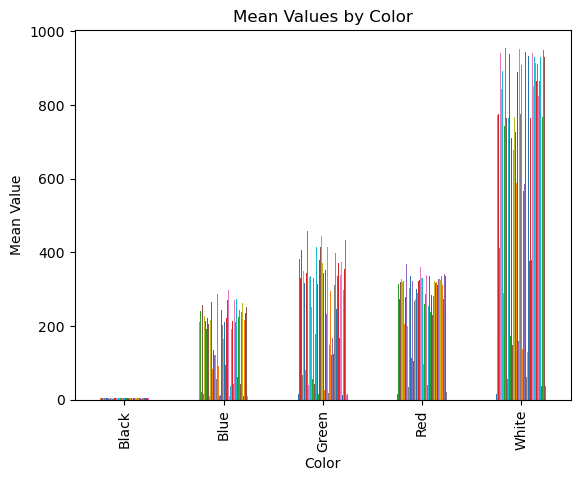

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_all_Mean.csv")

# Plot a bar chart with "Color" on the x-axis and the mean values on the y-axis
df.plot(x="Color", kind="bar", legend=None)

# Set labels and title
plt.xlabel("Color")
plt.ylabel("Mean Value")
plt.title("Mean Values by Color")

# Show the plot
plt.show()


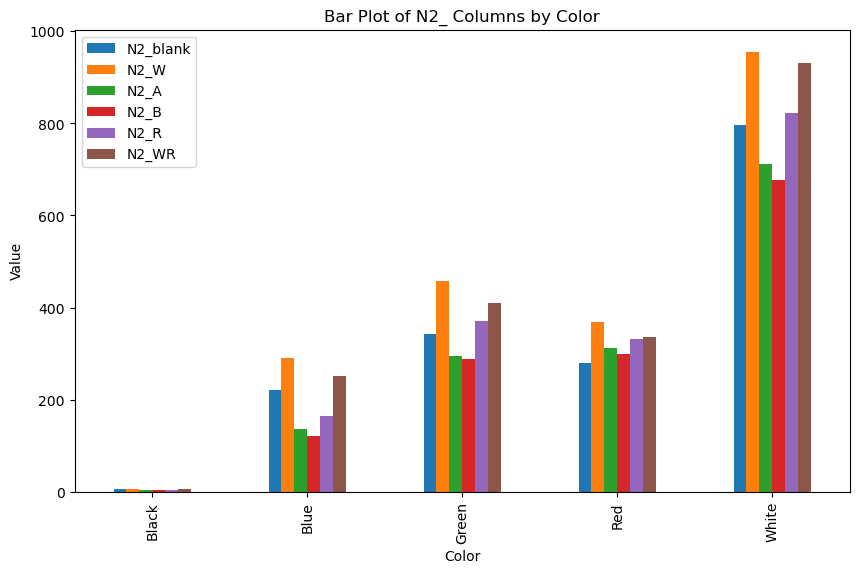

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_all_Mean.csv")

# Filter columns that start with "N2_"
n2_columns = [col for col in df.columns if col.startswith("N2_")]

# Set "Color" as the x-axis and "N2_" columns as the y-axis
df_plot = df[['Color'] + n2_columns]

# Set "Color" as the index for better plotting
df_plot = df_plot.set_index('Color')

# Create a bar plot
df_plot.plot(kind='bar', figsize=(10, 6))
plt.title("Bar Plot of N2_ Columns by Color")
plt.xlabel("Color")
plt.ylabel("Value")

# Show the plot
plt.show()



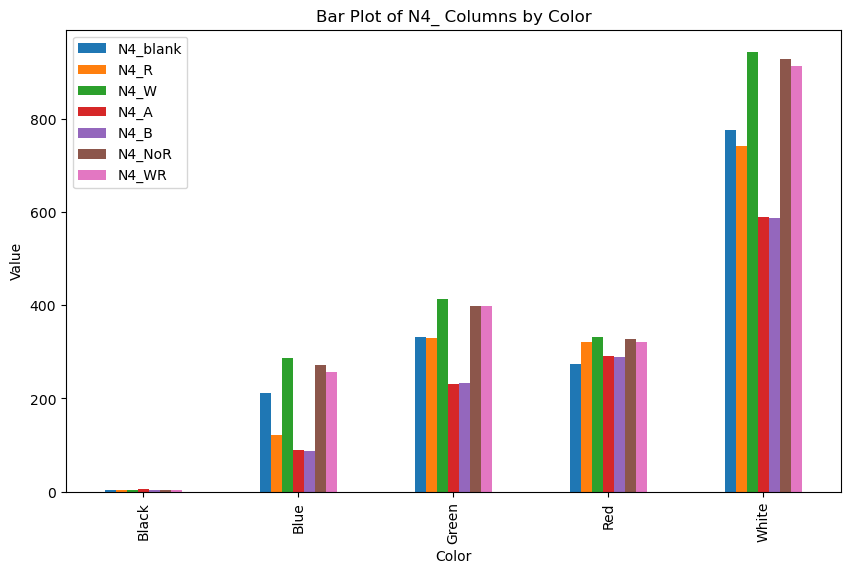

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_all_Mean.csv")

# Filter columns that start with "N4_"
n4_columns = [col for col in df.columns if col.startswith("N4_")]

# Set "Color" as the x-axis and "N4_" columns as the y-axis
df_plot = df[['Color'] + n4_columns]

# Set "Color" as the index for better plotting
df_plot = df_plot.set_index('Color')

# Create a bar plot
df_plot.plot(kind='bar', figsize=(10, 6))
plt.title("Bar Plot of N4_ Columns by Color")
plt.xlabel("Color")
plt.ylabel("Value")

# Show the plot
plt.show()


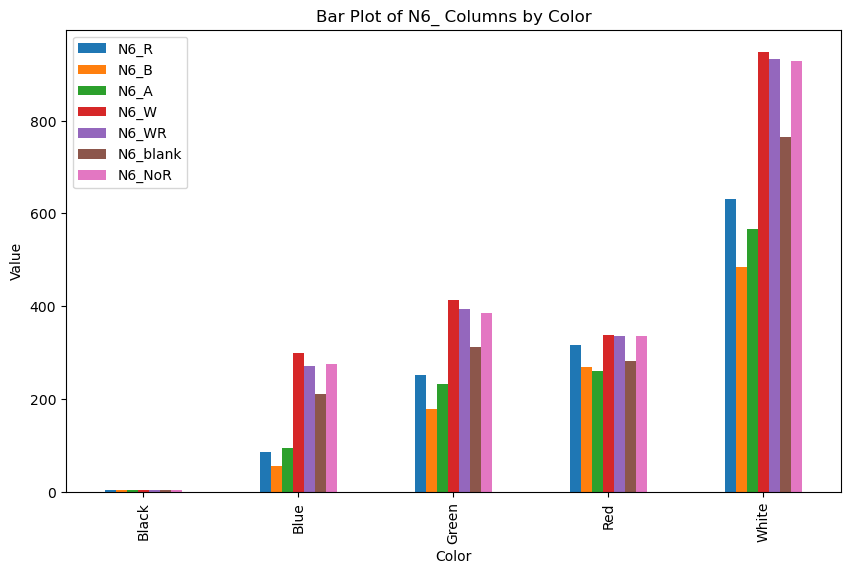

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_all_Mean.csv")

# Filter columns that start with "N6_"
n6_columns = [col for col in df.columns if col.startswith("N6_")]

# Set "Color" as the x-axis and "N6_" columns as the y-axis
df_plot = df[['Color'] + n6_columns]

# Set "Color" as the index for better plotting
df_plot = df_plot.set_index('Color')

# Create a bar plot
df_plot.plot(kind='bar', figsize=(10, 6))
plt.title("Bar Plot of N6_ Columns by Color")
plt.xlabel("Color")
plt.ylabel("Value")

# Show the plot
plt.show()


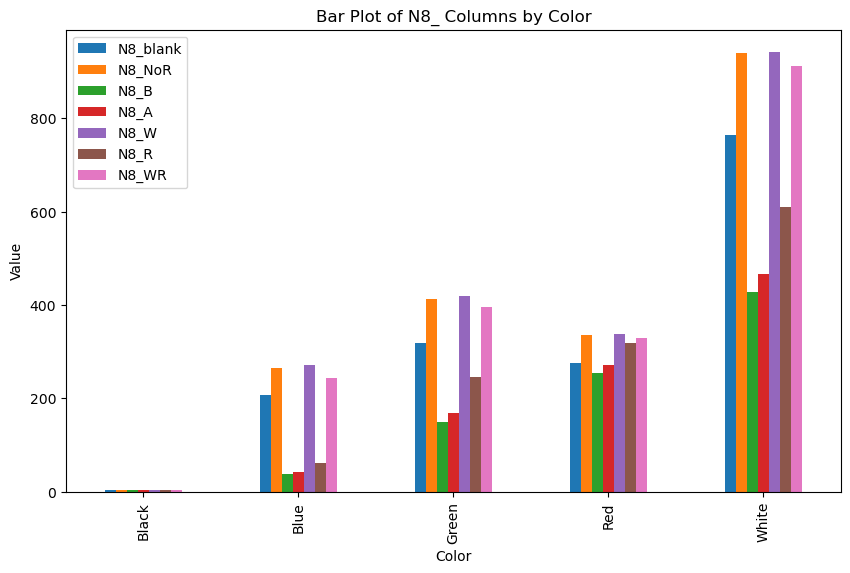

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_all_Mean.csv")

# Filter columns that start with "N8_"
n8_columns = [col for col in df.columns if col.startswith("N8_")]

# Set "Color" as the x-axis and "N8_" columns as the y-axis
df_plot = df[['Color'] + n8_columns]

# Set "Color" as the index for better plotting
df_plot = df_plot.set_index('Color')

# Create a bar plot
df_plot.plot(kind='bar', figsize=(10, 6))
plt.title("Bar Plot of N8_ Columns by Color")
plt.xlabel("Color")
plt.ylabel("Value")

# Show the plot
plt.show()


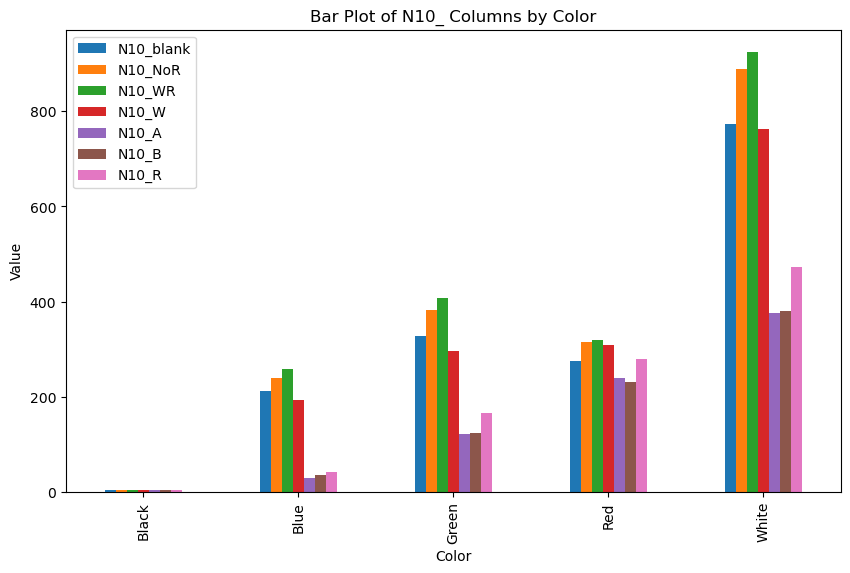

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_all_Mean.csv")

# Filter columns that start with "N10_"
n10_columns = [col for col in df.columns if col.startswith("N10_")]

# Set "Color" as the x-axis and "N2_" columns as the y-axis
df_plot = df[['Color'] + n10_columns]

# Set "Color" as the index for better plotting
df_plot = df_plot.set_index('Color')

# Create a bar plot
df_plot.plot(kind='bar', figsize=(10, 6))
plt.title("Bar Plot of N10_ Columns by Color")
plt.xlabel("Color")
plt.ylabel("Value")

# Show the plot
plt.show()


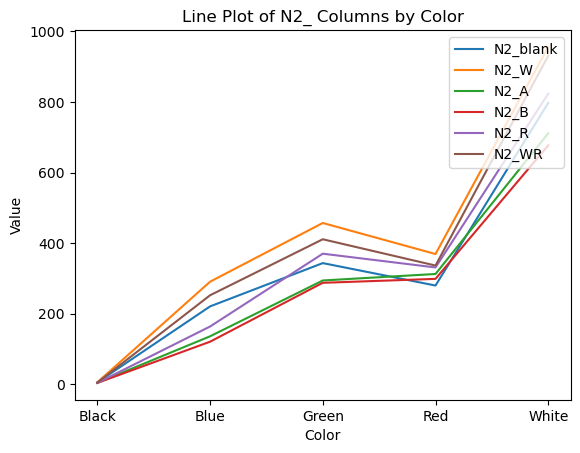

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_all_Mean.csv")

# Filter the columns starting with "N2_"
n2_columns = [col for col in df.columns if col.startswith("N2_")]

# Set "Color" column as the x-axis
x = df["Color"]

# Plot each "N2_" column as a separate line
for col in n2_columns:
    y = df[col]
    plt.plot(x, y, label=col)

# Customize the plot
plt.xlabel("Color")
plt.ylabel("Value")
plt.title("Line Plot of N2_ Columns by Color")
plt.legend(loc="upper right")

# Show the plot
plt.show()


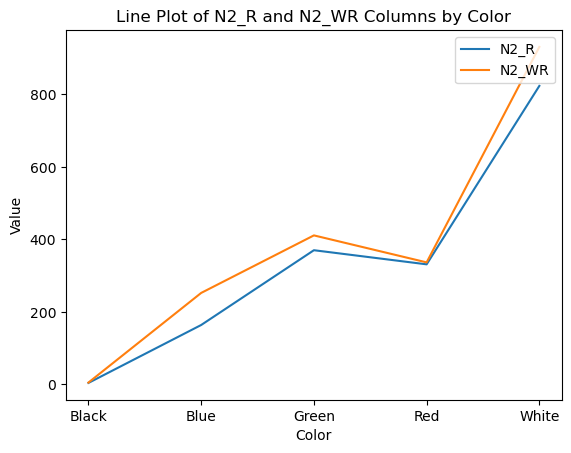

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_all_Mean.csv")

# Set "Color" column as the x-axis
x = df["Color"]

# Select the "N2_R" and "N2_WR" columns as the y-axis
y1 = df["N2_R"]
y2 = df["N2_WR"]

# Plot the "N2_R" and "N2_WR" columns as separate lines
plt.plot(x, y1, label="N2_R")
plt.plot(x, y2, label="N2_WR")

# Customize the plot
plt.xlabel("Color")
plt.ylabel("Value")
plt.title("Line Plot of N2_R and N2_WR Columns by Color")
plt.legend(loc="upper right")

# Show the plot
plt.show()


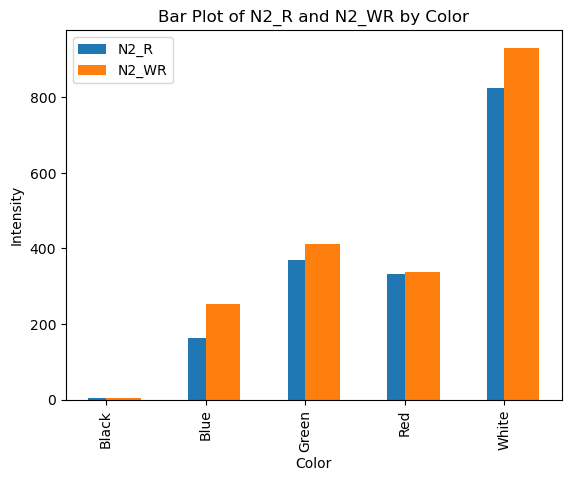

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_all_Mean.csv")

# Select the columns "Color," "N2_R," and "N2_WR"
df = df[["Color", "N2_R", "N2_WR"]]

# Set "Color" column as the x-axis
x = df["Color"]

# Set the values of "N2_R" and "N2_WR" as the y-axis
y1 = df["N2_R"]
y2 = df["N2_WR"]

# Define the width of the bars
bar_width = 0.35

# Set the x positions for the bars
x_indexes = range(len(x))

# Plot the "N2_R" and "N2_WR" values as side-by-side bars
plt.bar(x_indexes, y1, width=bar_width, label="N2_R", align="center")
plt.bar(x_indexes, y2, width=bar_width, label="N2_WR", align="edge")

# Customize the plot
plt.xlabel("Color")
plt.ylabel("Intensity")
plt.title("Bar Plot of N2_R and N2_WR by Color")
plt.xticks(x_indexes, x, rotation=90)
plt.legend()

# Show the plot
plt.show()



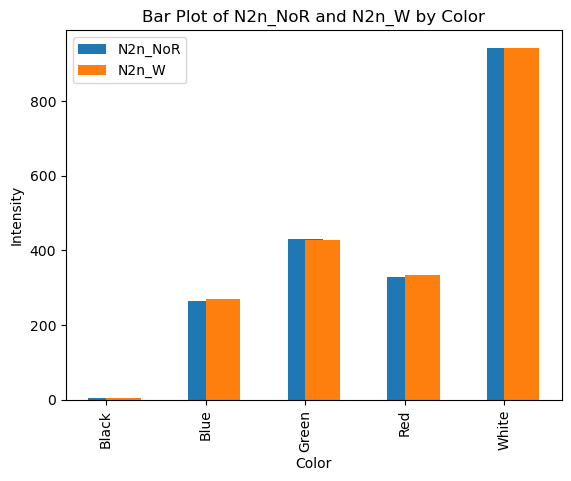

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_all_Mean.csv")

# Select the columns "Color," "N2_R," and "N2_WR"
df = df[["Color", "N2n_NoR", "N2n_W"]]

# Set "Color" column as the x-axis
x = df["Color"]

# Set the values of "N2_R" and "N2_WR" as the y-axis
y1 = df["N2n_NoR"]
y2 = df["N2n_W"]

# Define the width of the bars
bar_width = 0.35

# Set the x positions for the bars
x_indexes = range(len(x))

# Plot the "N2_R" and "N2_WR" values as side-by-side bars
plt.bar(x_indexes, y1, width=bar_width, label="N2n_NoR", align="center")
plt.bar(x_indexes, y2, width=bar_width, label="N2n_W", align="edge")

# Customize the plot
plt.xlabel("Color")
plt.ylabel("Intensity")
plt.title("Bar Plot of N2n_NoR and N2n_W by Color")
plt.xticks(x_indexes, x, rotation=90)
plt.legend()

# Show the plot
plt.show()



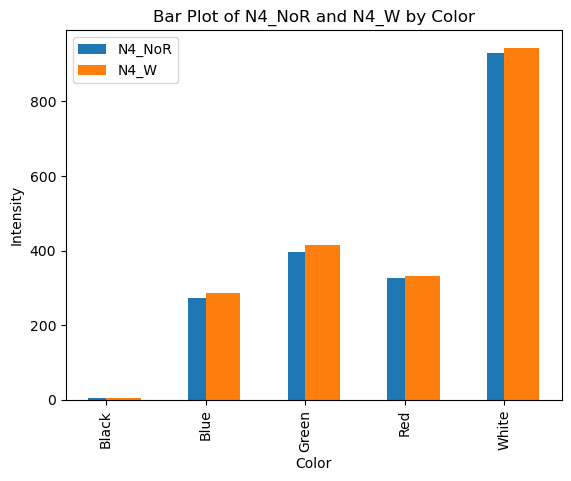

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_all_Mean.csv")

# Select the columns "Color," "N2_R," and "N2_WR"
df = df[["Color", "N4_NoR", "N4_W"]]

# Set "Color" column as the x-axis
x = df["Color"]

# Set the values of "N2_R" and "N2_WR" as the y-axis
y1 = df["N4_NoR"]
y2 = df["N4_W"]

# Define the width of the bars
bar_width = 0.35

# Set the x positions for the bars
x_indexes = range(len(x))

# Plot the "N2_R" and "N2_WR" values as side-by-side bars
plt.bar(x_indexes, y1, width=bar_width, label="N4_NoR", align="center")
plt.bar(x_indexes, y2, width=bar_width, label="N4_W", align="edge")

# Customize the plot
plt.xlabel("Color")
plt.ylabel("Intensity")
plt.title("Bar Plot of N4_NoR and N4_W by Color")
plt.xticks(x_indexes, x, rotation=90)
plt.legend()

# Show the plot
plt.show()



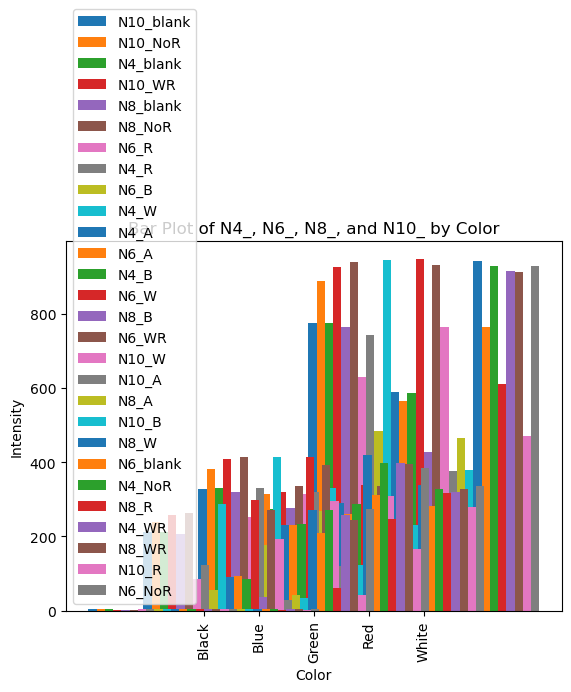

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_all_Mean.csv")

# Select the columns "Color," "N4_NoR," "N4_W," "N6_NoR," "N6_W," "N8_NoR," "N8_W," "N10_NoR," and "N10_W"
selected_columns = [col for col in df.columns if col.startswith("N4_") or col.startswith("N6_") or col.startswith("N8_") or col.startswith("N10_")]
df = df[["Color"] + selected_columns]

# Set "Color" column as the x-axis
x = df["Color"]

# Create a list of y-values for the selected columns
y_values = [df[col] for col in selected_columns]

# Define the width of the bars
bar_width = 0.15

# Set the x positions for the bars
x_indexes = range(len(x))

# Plot the values as side-by-side bars
for i, y in enumerate(y_values):
    plt.bar([x + i * bar_width for x in x_indexes], y, width=bar_width, label=selected_columns[i])

# Customize the plot
plt.xlabel("Color")
plt.ylabel("Intensity")
plt.title("Bar Plot of N4_, N6_, N8_, and N10_ by Color")
plt.xticks([x + bar_width * (len(selected_columns) - 1) / 2 for x in x_indexes], x, rotation=90)
plt.legend()

# Show the plot
plt.show()


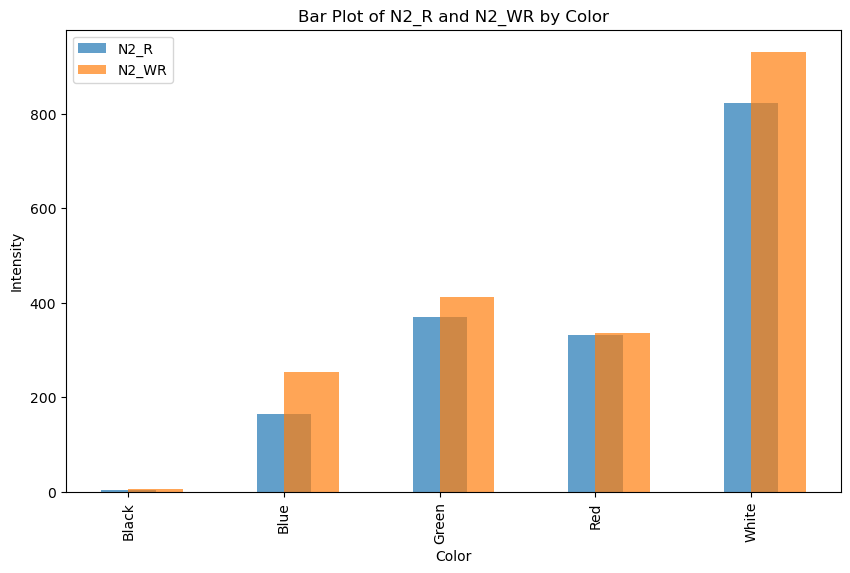

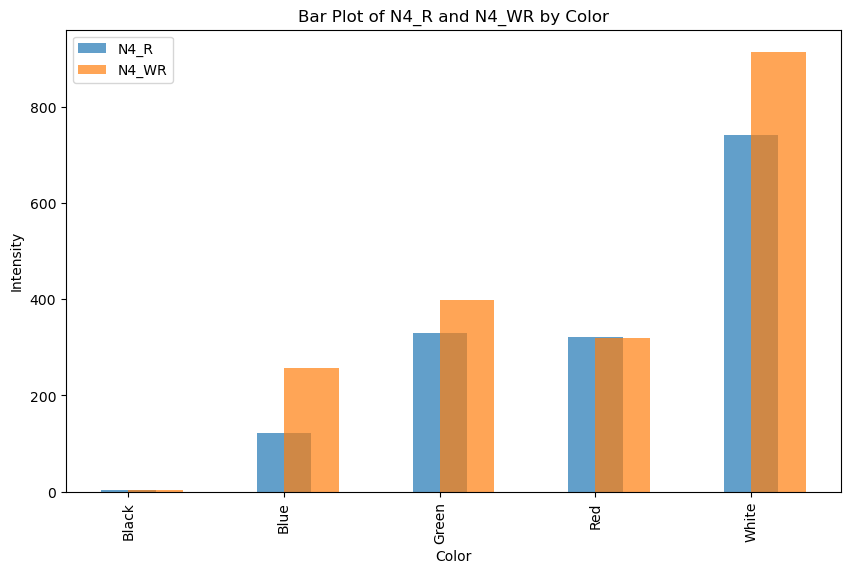

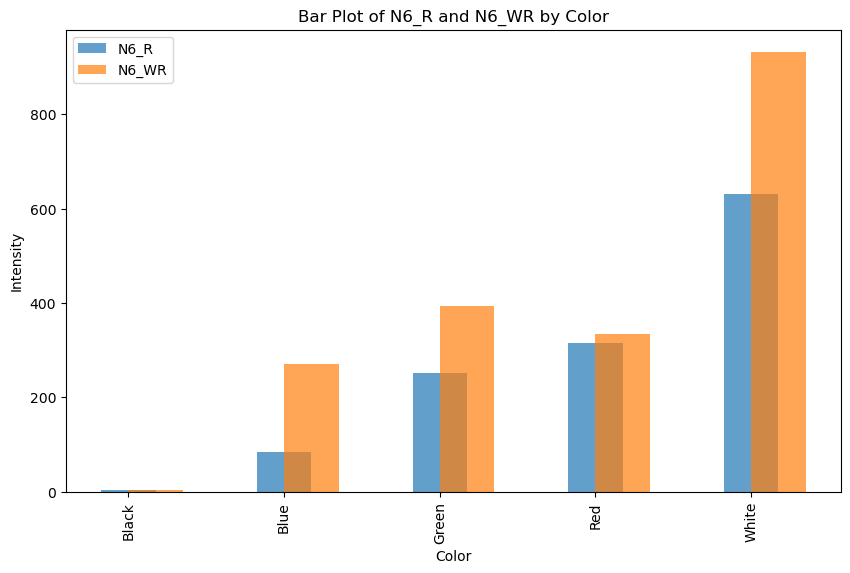

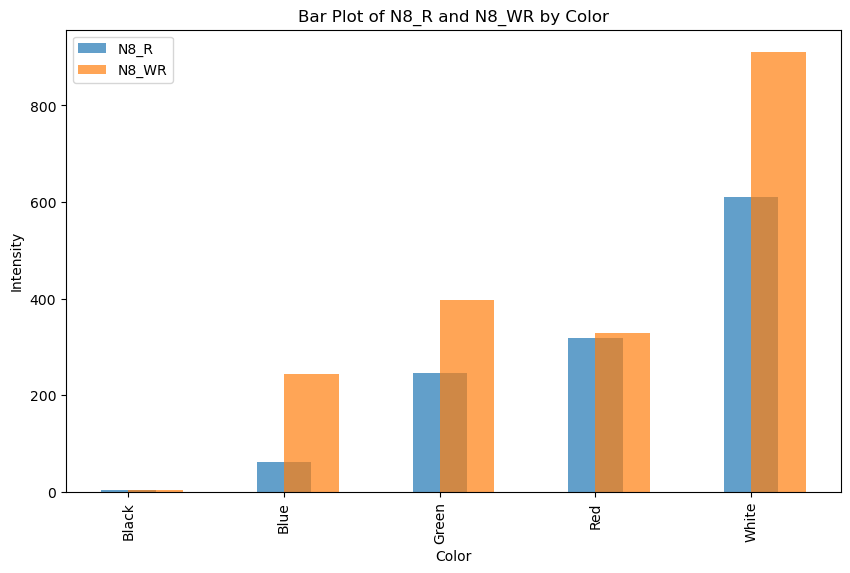

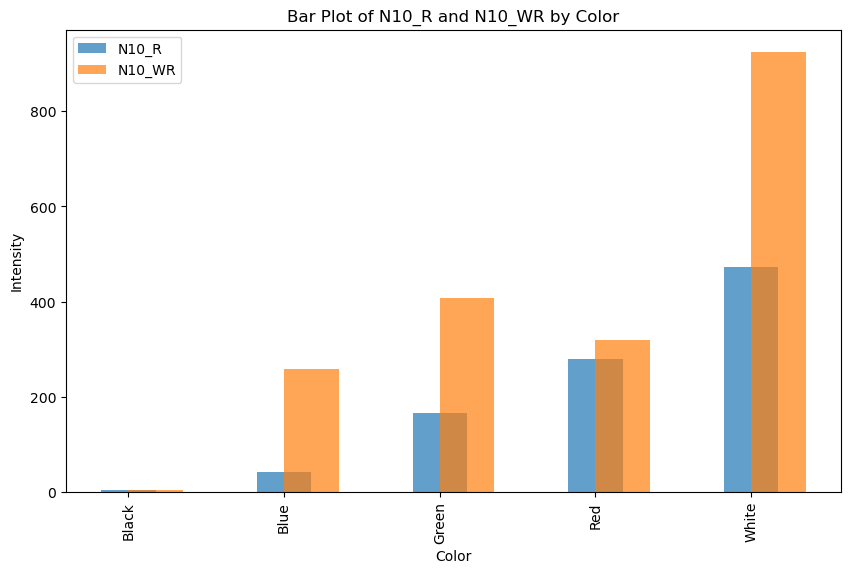

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_all_Mean.csv")

# Define the column pairs to plot
column_pairs = [("N2_R", "N2_WR"),("N4_R", "N4_WR"), ("N6_R", "N6_WR"), ("N8_R", "N8_WR"), ("N10_R", "N10_WR")]

# Set the width of the bars
bar_width = 0.35

# Get unique colors
colors = df["Color"].unique()

# Create a bar plot for each column pair
for col1, col2 in column_pairs:
    plt.figure(figsize=(10, 6))  # Create a new figure for each pair

    # Set "Color" column as the x-axis
    x = df["Color"]

    # Set the values of the two columns as the y-axis
    y1 = df[col1]
    y2 = df[col2]

    # Set the x positions for the bars
    x_indexes = range(len(x))

    # Plot the values as side-by-side bars
    plt.bar(x_indexes, y1, width=bar_width, label=col1, align="center", alpha=0.7)
    plt.bar(x_indexes, y2, width=bar_width, label=col2, align="edge", alpha=0.7)

    # Customize the plot
    plt.xlabel("Color")
    plt.ylabel("Intensity")
    plt.title(f"Bar Plot of {col1} and {col2} by Color")
    plt.xticks(x_indexes, x, rotation=90)
    plt.legend()

    # Show the plot
    plt.show()



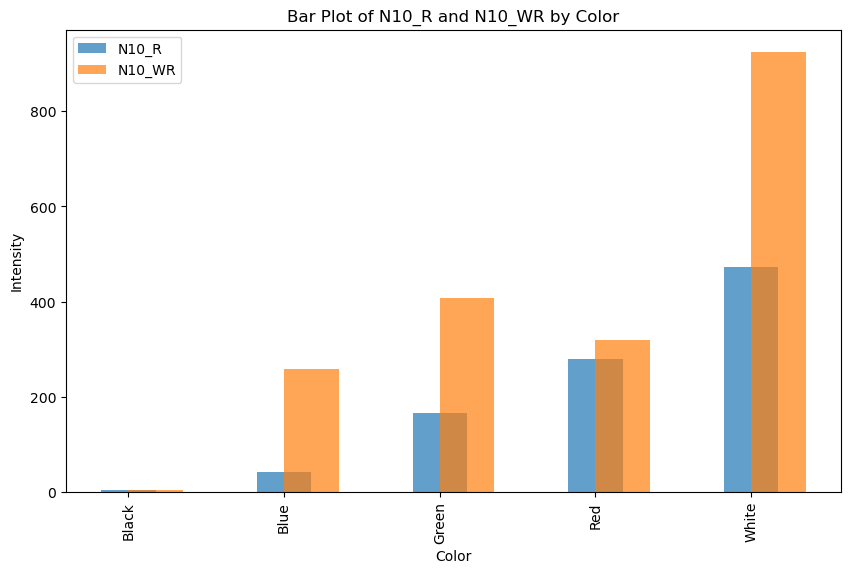

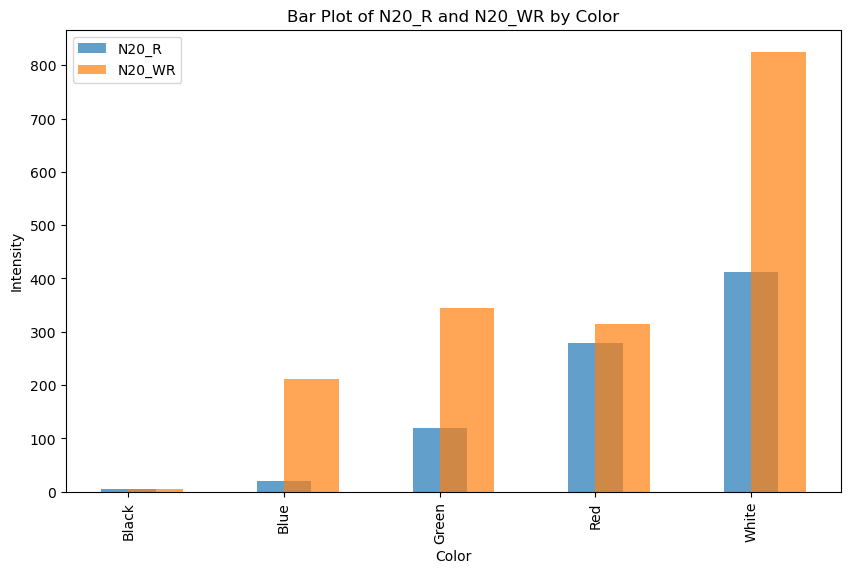

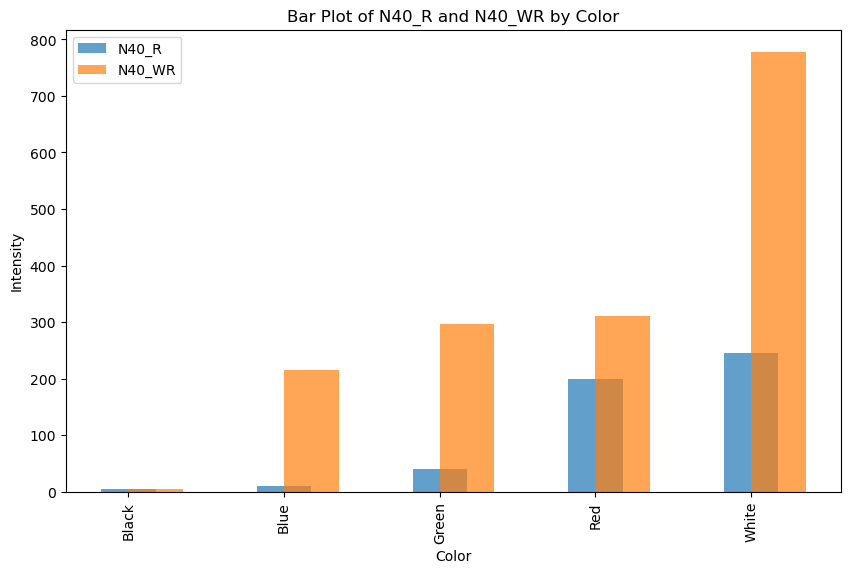

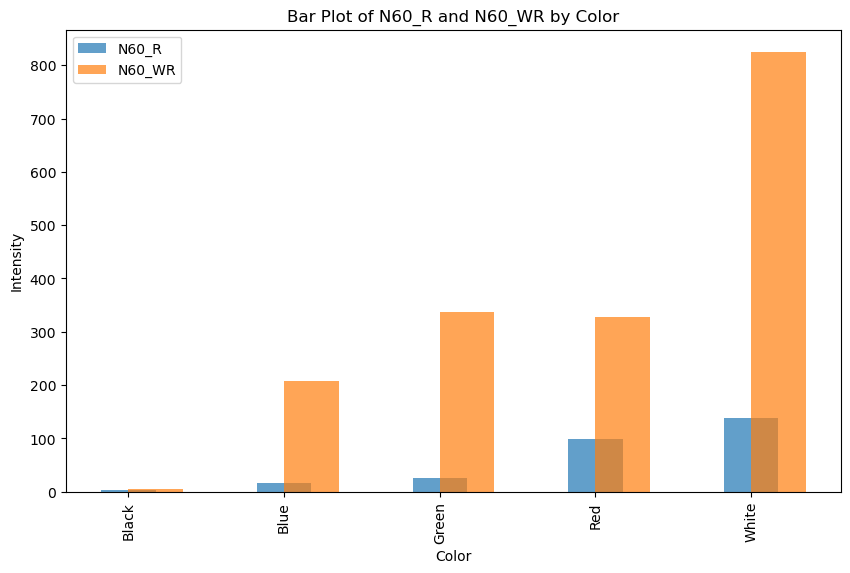

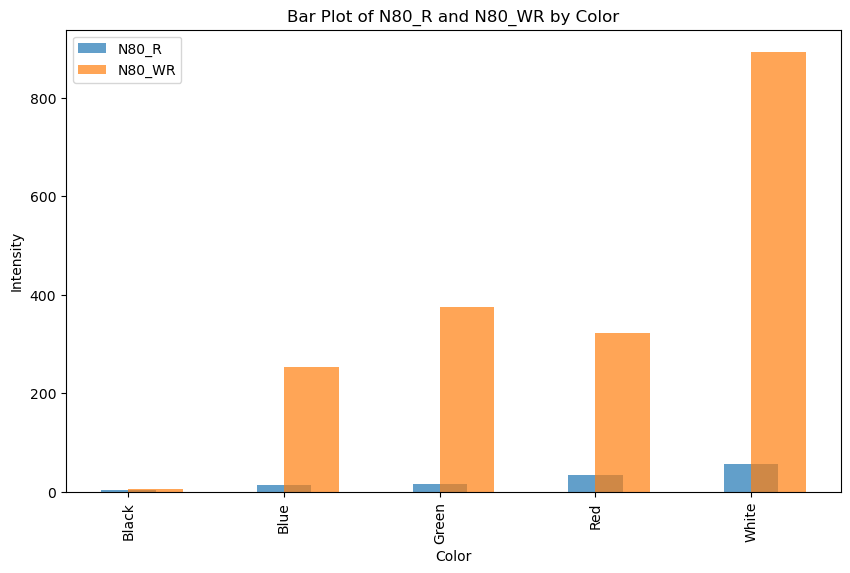

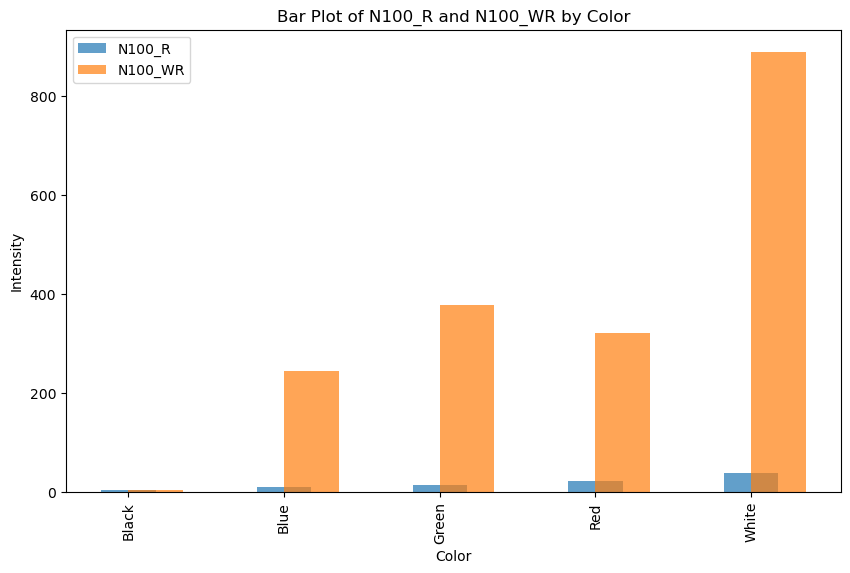

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_all_Mean.csv")

# Define the column pairs to plot
column_pairs = [("N10_R", "N10_WR"),("N20_R", "N20_WR"),("N40_R", "N40_WR"), ("N60_R", "N60_WR"), ("N80_R", "N80_WR"), ("N100_R", "N100_WR")]

# Set the width of the bars
bar_width = 0.35

# Get unique colors
colors = df["Color"].unique()

# Create a bar plot for each column pair
for col1, col2 in column_pairs:
    plt.figure(figsize=(10, 6))  # Create a new figure for each pair

    # Set "Color" column as the x-axis
    x = df["Color"]

    # Set the values of the two columns as the y-axis
    y1 = df[col1]
    y2 = df[col2]

    # Set the x positions for the bars
    x_indexes = range(len(x))

    # Plot the values as side-by-side bars
    plt.bar(x_indexes, y1, width=bar_width, label=col1, align="center", alpha=0.7)
    plt.bar(x_indexes, y2, width=bar_width, label=col2, align="edge", alpha=0.7)

    # Customize the plot
    plt.xlabel("Color")
    plt.ylabel("Intensity")
    plt.title(f"Bar Plot of {col1} and {col2} by Color")
    plt.xticks(x_indexes, x, rotation=90)
    plt.legend()

    # Show the plot
    plt.show()



In [20]:
import os
import pandas as pd

# Specify the folder path
folder_path = "NdatasetCSV"

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

# Create empty DataFrames to store the calculated statistics
average_intensity_df = pd.DataFrame()
std_dev_intensity_df = pd.DataFrame()

# Loop through each CSV file and calculate statistics for 'Intensity' column
for csv_file in csv_files:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Read the CSV file into a DataFrame
    df = pd.read_csv(file_path)

    # Check if 'Intensity' column exists in the DataFrame
    if 'Intensity' in df.columns:
        # Group data by 'Order' and 'Color' columns, then calculate mean and standard deviation
        grouped_data = df.groupby(['Order', 'Color'])['Intensity']
        mean_intensity = grouped_data.mean()
        std_dev_intensity = grouped_data.std()

        # Combine the calculated statistics into the DataFrames
        average_intensity_df[csv_file] = mean_intensity
        std_dev_intensity_df[csv_file] = std_dev_intensity
    else:
        print(f"Intensity column not found in file: {csv_file}")

# Load and process data from the "BG_0.csv" file
bg_file_path = "NdatasetCSV/BG_0.csv"  # Update this path as needed

bg_df = pd.read_csv(bg_file_path)

# Check if 'Intensity' column exists in the BG DataFrame
if 'Intensity' in bg_df.columns:
    # Group data by 'Order' and 'Color' columns, then calculate mean and standard deviation
    grouped_data_bg = bg_df.groupby(['Order', 'Color'])['Intensity']
    mean_intensity_bg = grouped_data_bg.mean()
    std_dev_intensity_bg = grouped_data_bg.std()

    # Combine the calculated statistics from the BG data into the DataFrames
    average_intensity_df["BG_0.csv"] = mean_intensity_bg
    std_dev_intensity_df["BG_0.csv"] = std_dev_intensity_bg
else:
    print("Intensity column not found in file: BG_0.csv")

# Save the calculated statistics as CSV files
output_folder = "StandardData"
output_mean_filename = "N_Mean.csv"
output_stddev_filename = "N_StdDev.csv"
output_mean_path = os.path.join(output_folder, output_mean_filename)
output_stddev_path = os.path.join(output_folder, output_stddev_filename)

# Create the "StandardData" folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Save the DataFrames as CSV files
average_intensity_df.to_csv(output_mean_path)
std_dev_intensity_df.to_csv(output_stddev_path)

# Print the calculated statistics
print("Average Intensity Values:")
print(average_intensity_df)

print("\nStandard Deviation of Intensity Values:")
print(std_dev_intensity_df)

print(f"Calculated statistics saved to {output_mean_path} and {output_stddev_path}")


Average Intensity Values:
             N10_blank.csv  N10_NoR.csv  N4_blank.csv  N20_R.csv  N10_WR.csv  \
Order Color                                                                    
6     Black           3.50         3.00          4.50       4.00        3.25   
      Blue          211.25       240.75        209.75      20.75      259.00   
      Green         326.75       378.50        329.00     120.50      405.00   
      Red           274.75       314.00        275.00     278.50      319.75   
      White         770.75       891.75        774.25     409.25      923.00   
...                    ...          ...           ...        ...         ...   
24    Black           3.00         3.50          4.25       4.75        3.50   
      Blue          212.75       242.25        209.50      20.25      259.25   
      Green         327.75       382.25        331.25     120.50      408.00   
      Red           274.75       315.50        273.25     278.50      320.00   
      White   

In [21]:
import pandas as pd

# Define the path to the N_Mean.csv file
n_mean_file_path = "StandardData/N_Mean.csv"  # Update the path as needed

# Read the CSV file into a DataFrame
n_mean_df = pd.read_csv(n_mean_file_path)

# Display the contents of the DataFrame
print("Data in N_Mean.csv:")
print(n_mean_df)


Data in N_Mean.csv:
    Order  Color  N10_blank.csv  N10_NoR.csv  N4_blank.csv  N20_R.csv  \
0       6  Black           3.50         3.00          4.50       4.00   
1       6   Blue         211.25       240.75        209.75      20.75   
2       6  Green         326.75       378.50        329.00     120.50   
3       6    Red         274.75       314.00        275.00     278.50   
4       6  White         770.75       891.75        774.25     409.25   
..    ...    ...            ...          ...           ...        ...   
90     24  Black           3.00         3.50          4.25       4.75   
91     24   Blue         212.75       242.25        209.50      20.25   
92     24  Green         327.75       382.25        331.25     120.50   
93     24    Red         274.75       315.50        273.25     278.50   
94     24  White         772.00       888.25        776.50     411.50   

    N10_WR.csv  N2n_NoR.csv  N20_A.csv  N20_W.csv  ...  N40_NoR.csv  \
0         3.25         5.00     

In [22]:
import pandas as pd

# Read the CSV file into a DataFrame
file_path = "StandardData/N_Mean.csv"
mean_df = pd.read_csv(file_path)

# Select columns that start with "N2," "N4," "N6," "N8," "N10," and "BG"
selected_columns = [col for col in mean_df.columns if col.startswith(("BG_","N2_","N4_","N6_","N8_","N10_"))]

# Create a new DataFrame with the selected columns
selected_mean_df = mean_df[selected_columns]

# Display the selected columns
print(selected_mean_df)



    N10_blank.csv  N10_NoR.csv  N4_blank.csv  N10_WR.csv  N2_blank.csv  \
0            3.50         3.00          4.50        3.25          5.75   
1          211.25       240.75        209.75      259.00        219.50   
2          326.75       378.50        329.00      405.00        344.25   
3          274.75       314.00        275.00      319.75        279.50   
4          770.75       891.75        774.25      923.00        796.50   
..            ...          ...           ...         ...           ...   
90           3.00         3.50          4.25        3.50          6.00   
91         212.75       242.25        209.50      259.25        220.75   
92         327.75       382.25        331.25      408.00        344.50   
93         274.75       315.50        273.25      320.00        280.25   
94         772.00       888.25        776.50      926.25        795.50   

    N2_W.csv  N8_blank.csv  N8_NoR.csv  N6_R.csv  N2_A.csv  ...  N6_blank.csv  \
0       5.50          3.50    

In [23]:
# Save the selected columns to a new CSV file
output_path = "StandardData/Selected_N_Mean.csv"
selected_mean_df.to_csv(output_path, index=False)

print(f"Selected data saved to {output_path}")


Selected data saved to StandardData/Selected_N_Mean.csv


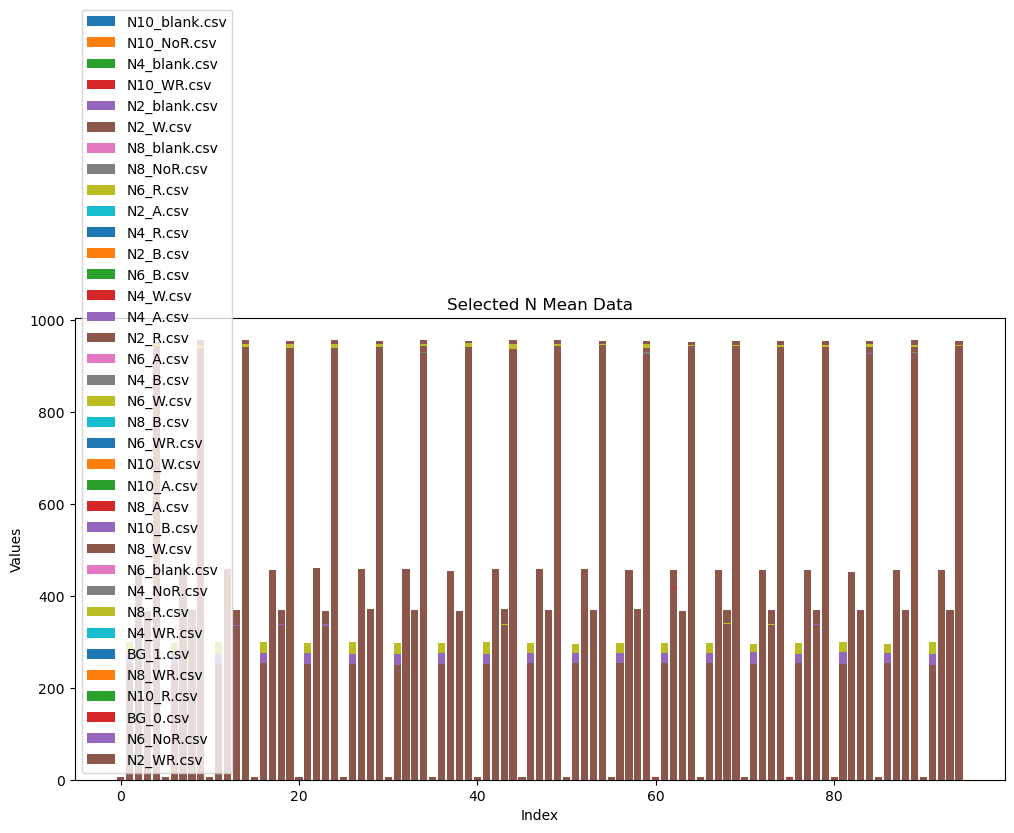

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file into a DataFrame
file_path = "StandardData/Selected_N_Mean.csv"
mean_df = pd.read_csv(file_path)

# Create a bar chart for each column
plt.figure(figsize=(12, 6))  # Set the figure size

# Iterate through columns and create a bar chart for each
for col in mean_df.columns:
    if col != 'BG_0':  # Exclude the 'BG_0' column
        plt.bar(mean_df.index, mean_df[col], label=col)

# Add labels and legend
plt.xlabel("Index")
plt.ylabel("Values")
plt.legend()

# Show the plot
plt.title("Selected N Mean Data")
plt.show()


/var/folders/x0/v1wddh8s0c32rk82mvdl7hf40000gn/T/ipykernel_59224/3246085115.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_mean_df['Order'] = range(1, len(selected_mean_df) + 1)


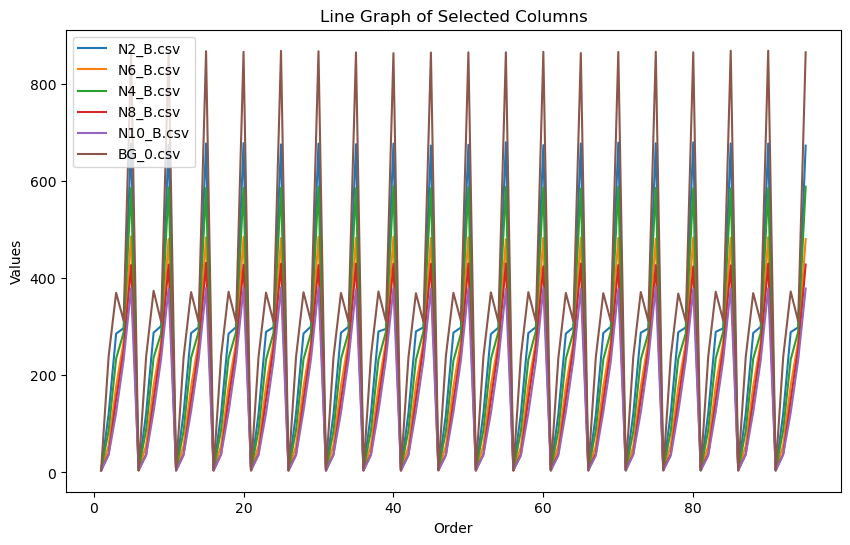

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file into a DataFrame
file_path = "StandardData/Selected_N_Mean.csv"
mean_df = pd.read_csv(file_path)

# Select columns that start with "N2," "N4," "N6," "N8," "N10," and "BG"
selected_columns = [col for col in mean_df.columns if col.startswith(("BG_0","N2_B","N4_B","N6_B","N8_B","N10_B"))]

# Create a new DataFrame with the selected columns
selected_mean_df = mean_df[selected_columns]

# Add an "Order" column to represent the order of the data
selected_mean_df['Order'] = range(1, len(selected_mean_df) + 1)

# Set the "Order" column as the index
selected_mean_df.set_index('Order', inplace=True)

# Plot a line graph
selected_mean_df.plot(kind='line', figsize=(10, 6))

# Set axis labels and a title
plt.xlabel('Order')
plt.ylabel('Values')
plt.title('Line Graph of Selected Columns')

# Show the plot
plt.show()
